In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.special import gammaln

from scripts.utils import check_data, update_data, preprocess_data, save_data
from scripts.utils import DATA_PATH, ANNDATA_MAP
from scripts.gene_subsampling import neyman_subsample, thinning


%load_ext autoreload
%autoreload 2

c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
celltype="Endothelial cells"

endothelial_cells = check_data(celltype=celltype,data_path=DATA_PATH)
if endothelial_cells is None:
    endothelial_cells = preprocess_data(celltype=celltype, with_subsets_config=True, n_neighbors=15, n_comps=100, random_state=42, verbose=False)
    save_data(data=endothelial_cells, data_path=f"{DATA_PATH}\\{ANNDATA_MAP[celltype]}")

In [17]:
endothelial_cells =neyman_subsample(data=endothelial_cells,target_labels=["Endothelial cells"],label_col="celltype_label",stratify_by=["cellstates_tme"],n_target=101)


Ratio=0.100


Ratio=0.200


Ratio=0.300


c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)




Ratio=0.400


c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)




Ratio=0.500


...

c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)




Ratio=0.900


c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)




Ratio=1.000


c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


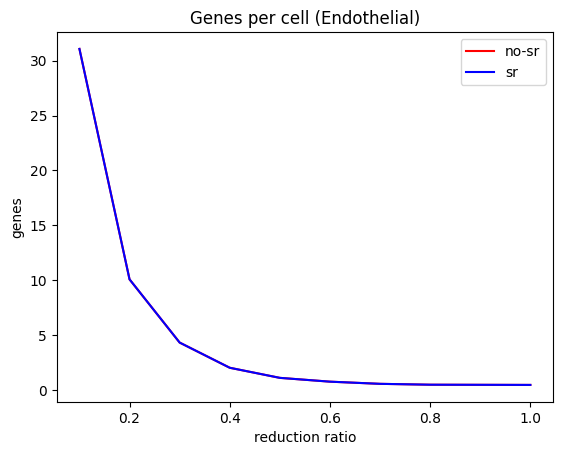

In [18]:
### Gènes par cellules
ratio_candidates = np.linspace(0.1,1,10)
n_genes_per_cell_list = []
n_genes_same_reads_list = []


for ratio in ratio_candidates:
    print(f"Ratio={ratio:.3f}")
    thinned_endothelialcells = thinning(endothelial_cells,reduction_ratio=ratio,same_reads=False,copy=False)
    thinned_endothelialcells = update_data(thinned_endothelialcells)

    thinned_endothelialcells_sr = thinning(endothelial_cells,reduction_ratio=ratio,same_reads=True,copy=False)
    thinned_endothelialcells_sr = update_data(thinned_endothelialcells_sr)
    
    n_genes_per_cell = (sp.csr_matrix.expm1(thinned_endothelialcells.raw.X) > 0).sum(axis=1)
    n_genes_per_cell_list.append(np.mean(n_genes_per_cell))

    n_genes_sr = (sp.csr_matrix.expm1(thinned_endothelialcells_sr.raw.X) > 0).sum(axis=1)
    n_genes_same_reads_list.append(np.mean(n_genes_sr))
    print("\n")

plt.plot(ratio_candidates,n_genes_per_cell_list,color="red",label="no-sr")
plt.plot(ratio_candidates,n_genes_same_reads_list,color="blue",label="sr")
plt.title(f"Genes per cell (Endothelial)")
plt.legend()
plt.xlabel("reduction ratio")
plt.ylabel("genes")
plt.show()

In [ ]:
def compute_theoretical_gene_richness(adata, p, layer=None):
    """
    Calcule l'espérance théorique du nombre de gènes détectés par cellule
    après un échantillonnage binomial de probabilité p.
    
    Formule : E[S_j] = sum_i (1 - (1 - p)^{X_{ij}})
    
    Parameters:
    -----------
    adata : AnnData
        Objet contenant les matrices de comptages.
    p : float
        Probabilité d'échantillonnage (0 <= p <= 1).
    layer : str, optional
        Nom du layer à utiliser.
        
    Returns:
    --------
    mean_expected_richness : float
        La moyenne (sur toutes les cellules) de l'espérance du nombre de gènes.
    """
    # 1. Extraction de la matrice
    X = adata.layers[layer] if layer is not None else adata.X
    
    if p <= 0:
        return 0.0
    if p >= 1:
        return np.mean((X > 0).sum(axis=1).A1 if sparse.issparse(X) else (X > 0).sum(axis=1))

    # 2. Calcul de la probabilité de détection par entrée non nulle
    # On calcule 1 - (1-p)^X uniquement pour les entrées non nulles (X_ij > 0)
    # car pour X_ij = 0, le terme (1 - (1-p)^0) est égal à 0.
    
    if sp.issparse(X):
        # Pour une matrice creuse, on opère sur l'attribut .data
        # Probabilité qu'au moins un count soit détecté pour chaque gène i dans cellule j
        prob_detected_data = 1 - np.power(1 - p, X.data)
        
        # On somme ces probabilités par ligne (cellule)
        # np.add.reduceat est très rapide pour les matrices CSR
        expected_genes_per_cell = np.add.reduceat(prob_detected_data, X.indptr[:-1])
    else:
        # Pour une matrice dense
        prob_detected_matrix = 1 - np.power(1 - p, X)
        expected_genes_per_cell = prob_detected_matrix.sum(axis=1)

    # 3. Retourne la moyenne sur toutes les cellules
    return np.mean(expected_genes_per_cell)

# Exemple d'utilisation
# e_richness = compute_theoretical_gene_richness(adata, p=0.05)

In [23]:
compute_theoretical_gene_richness(endothelial_cells.raw,0.01)

np.float64(14.079610363574924)

C:\Users\mayeu\AppData\Local\Temp\ipykernel_12352\2813674485.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


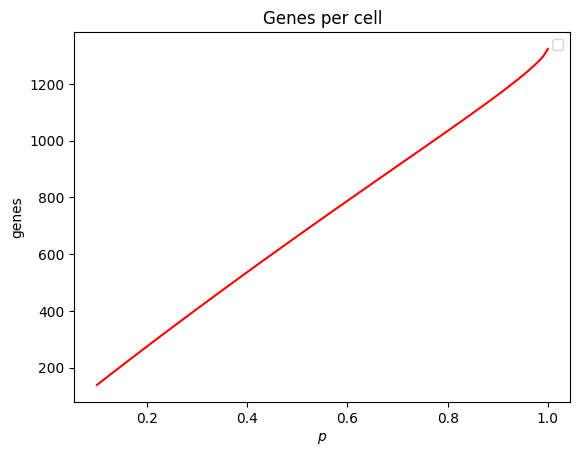

In [42]:
ratio_candidates = np.linspace(0.1,1,100)
n_genes_per_cell_list_th = []

for ratio in ratio_candidates:

    n_genes_per_cell_list_th.append(compute_theoretical_gene_richness(endothelial_cells.raw,ratio))

plt.plot(ratio_candidates,n_genes_per_cell_list_th,color="red")
plt.title(f"Genes per cell")
plt.legend()
plt.xlabel(rf"$p$")
plt.ylabel("genes")
plt.show()

In [ ]:
def log_combination(n, k):
    """
    Calcule ln(nCk) de manière stable via la fonction log-gamma.
    n et k peuvent être des vecteurs numpy.
    """
    # On gère les cas où k > n (probabilité 0)
    mask = (k >= 0) & (n >= k)
    res = np.full_like(n, -np.inf, dtype=float)
    
    res[mask] = gammaln(n[mask] + 1) - (gammaln(k[mask] + 1) + gammaln(n[mask] - k[mask] + 1))
    return res

def compute_expected_richness_hypergeometric(adata, p, layer=None):
    """
    Calcule l'espérance du nombre de gènes détectés SANS REMISE.
    Formule : E[S_j] = sum_i ( 1 - [ (N_j - n_ij)Ck_j / N_jCk_j ] )
    """
    X = adata.layers[layer] if layer is not None else adata.X
    
    if not sp.issparse(X):
        X = sp.csr_matrix(X)
    
    # N_j : Somme totale des counts originaux par cellule
    N_j = np.array(X.sum(axis=1)).flatten().astype(float)
    
    # k_j : Nombre de molécules "tirées" (taille de la nouvelle librairie)
    # On arrondit à l'entier le plus proche pour k_j
    k_j = np.round(N_j * p).astype(float)
    
    expected_richness_per_cell = np.zeros(adata.n_obs)

    # Extraction des données par ligne (cellule)
    for j in range(adata.n_obs):
        # n_ij : counts des gènes exprimés dans la cellule j
        start, end = X.indptr[j], X.indptr[j+1]
        n_ij = X.data[start:end].astype(float)
        
        if N_j[j] == 0 or k_j[j] == 0:
            expected_richness_per_cell[j] = 0
            continue

        # Log-probabilité que le gène i ne soit PAS tiré :
        # ln(P(X_ij = 0)) = ln( (N_j - n_ij)Ck_j ) - ln( N_jCk_j )
        ln_p_zero = log_combination(N_j[j] - n_ij, k_j[j]) - log_combination(N_j[j], k_j[j])
        
        # Probabilité de détection = 1 - exp(ln_p_zero)
        # On utilise clip pour éviter les erreurs numériques minuscules
        prob_detected = 1.0 - np.exp(ln_p_zero)
        
        expected_richness_per_cell[j] = np.sum(prob_detected)

    return np.mean(expected_richness_per_cell)

# Utilisation :
# richness_hyper = compute_expected_richness_hypergeometric(adata, p=0.8)

In [72]:
ratio_candidates = np.linspace(0.1,1,20)
ratio_candidates_th = np.linspace(0.1,1,100)

n_genes_per_cell_list = []
n_genes_same_reads_list = []


for ratio in ratio_candidates:
    print(f"Ratio={ratio:.3f}")
    thinned_endothelialcells = thinning(endothelial_cells,reduction_ratio=ratio,same_reads=False,copy=True)

    n = thinned_endothelialcells.raw.shape[0]
    n_genes_per_cell = ((np.floor(sp.csr_matrix.expm1(thinned_endothelialcells.raw.X).data).astype(int) > 0)).sum(axis=0)
    n_genes_per_cell_list.append(n_genes_per_cell/n)

plt.figure(4,4)
plt.plot(ratio_candidates,n_genes_per_cell_list,color="red")
plt.title(f"Genes per cell")
plt.legend()
plt.gca().invert_xaxis()
plt.xlabel(rf"$p$")
plt.ylabel("genes")
plt.show()

Ratio=0.100
Ratio=0.147
Ratio=0.195
Ratio=0.242
Ratio=0.289
Ratio=0.337
Ratio=0.384
Ratio=0.432
Ratio=0.479
Ratio=0.526
Ratio=0.574
Ratio=0.621
Ratio=0.668
Ratio=0.716
Ratio=0.763
Ratio=0.811
Ratio=0.858
Ratio=0.905
Ratio=0.953
Ratio=1.000


TypeError: Value after * must be an iterable, not int

In [24]:
ratio = 0.05
thinned_endothelialcells = thinning(endothelial_cells,reduction_ratio=ratio,same_reads=False,copy=True)

n = thinned_endothelialcells.raw.shape[0]
n_genes_per_cell = ((np.floor(sp.csr_matrix.expm1(thinned_endothelialcells.raw.X).data).astype(int) > 0)).sum(axis=0)


print(n_genes_per_cell / n)

140.41550429184548


C:\Users\mayeu\AppData\Local\Temp\ipykernel_12352\2701737428.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


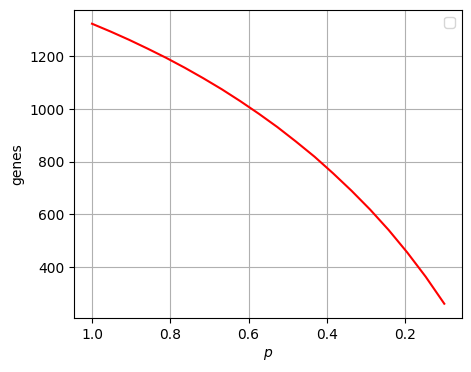

In [79]:
plt.figure(figsize=(5,4))
plt.plot(ratio_candidates,n_genes_per_cell_list,color="red")
plt.legend()
plt.gca().invert_xaxis()
plt.xlabel(rf"$p$")
plt.ylabel("genes")
plt.grid()
plt.show()

In [66]:
thinned_endothelialcells.raw.shape

(3728, 16638)

In [45]:
n_genes_per_cell = (sp.csr_matrix.expm1(endothelial_cells.raw.X) > 0).sum(axis=1)

In [47]:
np.mean(n_genes_per_cell)

np.float64(1322.9841738197424)

C:\Users\mayeu\AppData\Local\Temp\ipykernel_12352\2462469396.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


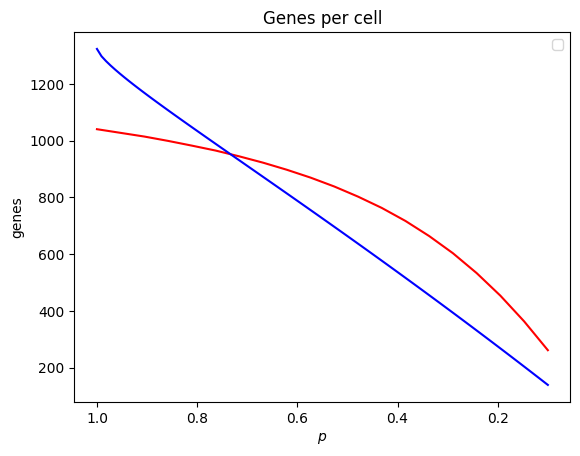

In [44]:
ratio_candidates = np.linspace(0.1,1,20)
ratio_candidates_th = np.linspace(0.1,1,100)


plt.plot(ratio_candidates,n_genes_per_cell_list,color="red")
plt.plot(ratio_candidates_th,n_genes_per_cell_list_th,color="blue")
plt.title(f"Genes per cell")
plt.legend()
plt.gca().invert_xaxis()
plt.xlabel(rf"$p$")
plt.ylabel("genes")
plt.show()

In [59]:
np.floor(np.expm1(endothelial_cells.raw.X[:20,:20].data)).astype(int)

array([3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1])

In [56]:
np.expm1(0)

np.float64(0.0)

In [ ]:
def log_combination(n, k):
    """
    Calcule ln(nCk) de manière stable via la fonction log-gamma.
    n et k peuvent être des vecteurs numpy.
    """
    # On gère les cas où k > n (probabilité 0)
    mask = (k >= 0) & (n >= k)
    res = np.full_like(n, -np.inf, dtype=float)
    
    res[mask] = gammaln(n[mask] + 1) - (gammaln(k[mask] + 1) + gammaln(n[mask] - k[mask] + 1))
    return res

def compute_expected_richness_hypergeometric(adata, p, layer=None):
    """
    Calcule l'espérance du nombre de gènes détectés SANS REMISE.
    Formule : E[S_j] = sum_i ( 1 - [ (N_j - n_ij)Ck_j / N_jCk_j ] )
    """
    X = adata.layers[layer] if layer is not None else adata.X

    X = X.expm1()                  # expm1
    X.data = np.floor(X.data)      # arrondi inférieur
    X.data = X.data.astype(int)
    
    if not sp.issparse(X):
        X = sp.csr_matrix(X)

    # N_j : Somme totale des counts originaux par cellule
    N_j = np.array(X.sum(axis=1)).flatten().astype(float)
    
    # k_j : Nombre de molécules "tirées" (taille de la nouvelle librairie)
    # On arrondit à l'entier le plus proche pour k_j
    k_j = np.round(N_j * p).astype(float)
    
    expected_richness_per_cell = np.zeros(adata.n_obs)

    # Extraction des données par ligne (cellule)
    for j in range(adata.n_obs):
        # n_ij : counts des gènes exprimés dans la cellule j
        start, end = X.indptr[j], X.indptr[j+1]
        n_ij = X.data[start:end].astype(float)
        
        if N_j[j] == 0 or k_j[j] == 0:
            expected_richness_per_cell[j] = 0
            continue

        # Log-probabilité que le gène i ne soit PAS tiré :
        # ln(P(X_ij = 0)) = ln( (N_j - n_ij)Ck_j ) - ln( N_jCk_j )
        ln_p_zero = log_combination(N_j[j] - n_ij, k_j[j]) - log_combination(N_j[j], k_j[j])
        
        # Probabilité de détection = 1 - exp(ln_p_zero)
        # On utilise clip pour éviter les erreurs numériques minuscules
        prob_detected = 1.0 - np.exp(ln_p_zero)
        
        expected_richness_per_cell[j] = np.sum(prob_detected)

    return np.mean(expected_richness_per_cell)

# Utilisation :
richness_hyper = compute_expected_richness_hypergeometric(endothelial_cells.raw, p=0.8)

IndexError: invalid index to scalar variable.